In [1]:
# ============================================
# PHASE 3: LOAD PHASE 1 & 2 DATA
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, pearsonr
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("Loading Phase 1 & 2 data...")

# Load diversity metrics from Phase 1
diversity_df = pd.read_csv('../results/diversity_metrics_phase1.csv')

# Load bacteria fold changes from Phase 2
fold_changes_df = pd.read_csv('../results/bacteria_fold_changes.csv')

# Recreate feature_matrix (with disease labels added in Phase 2)
# This is just the synthetic data recreated:
np.random.seed(42)
n_samples = 100
n_bacteria = 50
abundance_data = np.random.multinomial(10000, np.ones(n_bacteria)/n_bacteria, n_samples)
abundance_df = pd.DataFrame(abundance_data, columns=[f'Bacteria_{i}' for i in range(n_bacteria)])

# Add disease status (same as Phase 2)
disease_status = ['healthy'] * 50 + ['IBD'] * 50
abundance_df_modified = abundance_df.astype(float).copy()
for i in range(50, 100):
    abundance_df_modified.iloc[i, :] = abundance_df_modified.iloc[i, :] * 0.5
    abundance_df_modified.iloc[i, 0] = abundance_df_modified.iloc[i, 0] * 3

feature_matrix = abundance_df_modified.copy()
feature_matrix['disease_status'] = disease_status

print(f"✅ Loaded Phase 1 & 2 data!")
print(f"✅ Feature matrix: {feature_matrix.shape}")

Loading Phase 1 & 2 data...
✅ Loaded Phase 1 & 2 data!
✅ Feature matrix: (100, 51)


In [2]:
# ============================================
# PHASE 3: STATISTICAL FEATURE SELECTION
# ============================================

print("\n" + "="*60)
print("PHASE 3: FEATURE SELECTION & DIMENSIONALITY REDUCTION")
print("="*60)

# ANOVA: Test each bacteria independently
# Null hypothesis: All groups have same mean
# Alternative: At least one group differs

from scipy.stats import f_oneway, pearsonr

print("\n" + "="*60)
print("TASK 1: ANOVA TESTING (Which bacteria differ?)")
print("="*60)

bacteria_cols = [col for col in feature_matrix.columns if col.startswith('Bacteria')]

# Split by disease
healthy_data = feature_matrix[feature_matrix['disease_status'] == 'healthy'][bacteria_cols]
ibd_data = feature_matrix[feature_matrix['disease_status'] == 'IBD'][bacteria_cols]

# Run ANOVA for each bacteria
anova_results = []

for bacteria in bacteria_cols:
    # ANOVA F-test
    f_stat, p_value = f_oneway(healthy_data[bacteria], ibd_data[bacteria])
    
    # Effect size (eta-squared): How much variance is explained?
    # eta² = (MS_between) / (MS_total)
    grand_mean = feature_matrix[bacteria].mean()
    ss_between = (len(healthy_data) * (healthy_data[bacteria].mean() - grand_mean)**2 +
                  len(ibd_data) * (ibd_data[bacteria].mean() - grand_mean)**2)
    ss_total = ((feature_matrix[bacteria] - grand_mean)**2).sum()
    eta_squared = ss_between / ss_total if ss_total > 0 else 0
    
    anova_results.append({
        'bacteria': bacteria,
        'f_statistic': f_stat,
        'p_value': p_value,
        'eta_squared': eta_squared,
        'significant': p_value < 0.05
    })

# Convert to DataFrame and sort by significance
anova_df = pd.DataFrame(anova_results)
anova_df = anova_df.sort_values('f_statistic', ascending=False)

print(f"\n🧪 ANOVA RESULTS (All {len(anova_df)} bacteria)")
print("-" * 80)
print(f"Significant bacteria (p < 0.05): {anova_df['significant'].sum()}")
print(f"Non-significant bacteria (p >= 0.05): {(~anova_df['significant']).sum()}")

print("\n🏆 TOP 20 MOST DISCRIMINATIVE BACTERIA")
print("-" * 80)
top_20 = anova_df.head(20)
for idx, (_, row) in enumerate(top_20.iterrows(), 1):
    sig = "✅" if row['significant'] else "  "
    print(f"{idx:2d}. {sig} {row['bacteria']:15} | F={row['f_statistic']:8.2f} | p={row['p_value']:.2e} | η²={row['eta_squared']:.4f}")

# Save ANOVA results
anova_df.to_csv('../results/phase3_anova_results.csv', index=False)
print("\n✅ Saved: phase3_anova_results.csv")

# Keep top 20 bacteria for next steps
top_20_bacteria = top_20['bacteria'].tolist()
print(f"\n✅ Selected top 20 bacteria for ML model")


PHASE 3: FEATURE SELECTION & DIMENSIONALITY REDUCTION

TASK 1: ANOVA TESTING (Which bacteria differ?)

🧪 ANOVA RESULTS (All 50 bacteria)
--------------------------------------------------------------------------------
Significant bacteria (p < 0.05): 50
Non-significant bacteria (p >= 0.05): 0

🏆 TOP 20 MOST DISCRIMINATIVE BACTERIA
--------------------------------------------------------------------------------
 1. ✅ Bacteria_27     | F= 3117.73 | p=4.22e-76 | η²=0.9695
 2. ✅ Bacteria_3      | F= 2928.19 | p=8.29e-75 | η²=0.9676
 3. ✅ Bacteria_29     | F= 2829.79 | p=4.19e-74 | η²=0.9665
 4. ✅ Bacteria_4      | F= 2815.71 | p=5.30e-74 | η²=0.9664
 5. ✅ Bacteria_5      | F= 2751.13 | p=1.59e-73 | η²=0.9656
 6. ✅ Bacteria_19     | F= 2614.51 | p=1.77e-72 | η²=0.9639
 7. ✅ Bacteria_14     | F= 2533.27 | p=7.86e-72 | η²=0.9628
 8. ✅ Bacteria_33     | F= 2396.49 | p=1.08e-70 | η²=0.9607
 9. ✅ Bacteria_17     | F= 2346.06 | p=2.93e-70 | η²=0.9599
10. ✅ Bacteria_37     | F= 2301.97 | p=7.15e-

In [3]:
# ============================================
# TASK 2: CORRELATION ANALYSIS
# ============================================

print("\n" + "="*60)
print("TASK 2: CORRELATION ANALYSIS")
print("="*60)

# Calculate correlation matrix for top 20 bacteria
top_20_data = feature_matrix[top_20_bacteria]
correlation_matrix = top_20_data.corr()

print("\nCorrelation Matrix (20 × 20):")
print(f"Shape: {correlation_matrix.shape}")

# Find strongest correlations (excluding diagonal)
strong_correlations = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.7:  # Strong correlation threshold
            strong_correlations.append({
                'bacteria_1': correlation_matrix.columns[i],
                'bacteria_2': correlation_matrix.columns[j],
                'correlation': corr_value
            })

strong_corr_df = pd.DataFrame(strong_correlations)
strong_corr_df = strong_corr_df.sort_values('correlation', ascending=False, key=abs)

print(f"\n🔗 STRONG CORRELATIONS (|r| > 0.7)")
print("-" * 80)
print(f"Found {len(strong_corr_df)} strong correlations:")
for idx, row in strong_corr_df.head(10).iterrows():
    direction = "↑↑" if row['correlation'] > 0 else "↑↓"
    print(f"{direction} {row['bacteria_1']} ↔ {row['bacteria_2']:15} | r={row['correlation']:6.3f}")

# Save correlation matrix
correlation_matrix.to_csv('../results/phase3_correlation_matrix.csv')
print("\n✅ Saved: phase3_correlation_matrix.csv")


TASK 2: CORRELATION ANALYSIS

Correlation Matrix (20 × 20):
Shape: (20, 20)

🔗 STRONG CORRELATIONS (|r| > 0.7)
--------------------------------------------------------------------------------
Found 190 strong correlations:
↑↑ Bacteria_19 ↔ Bacteria_42     | r= 0.974
↑↑ Bacteria_4 ↔ Bacteria_14     | r= 0.972
↑↑ Bacteria_27 ↔ Bacteria_29     | r= 0.972
↑↑ Bacteria_27 ↔ Bacteria_6      | r= 0.972
↑↑ Bacteria_19 ↔ Bacteria_34     | r= 0.972
↑↑ Bacteria_4 ↔ Bacteria_37     | r= 0.971
↑↑ Bacteria_27 ↔ Bacteria_4      | r= 0.971
↑↑ Bacteria_5 ↔ Bacteria_20     | r= 0.970
↑↑ Bacteria_5 ↔ Bacteria_19     | r= 0.970
↑↑ Bacteria_3 ↔ Bacteria_33     | r= 0.970

✅ Saved: phase3_correlation_matrix.csv



TASK 3: CREATING VISUALIZATIONS
✅ Plot 1 saved: 06_anova_top20_bacteria.png


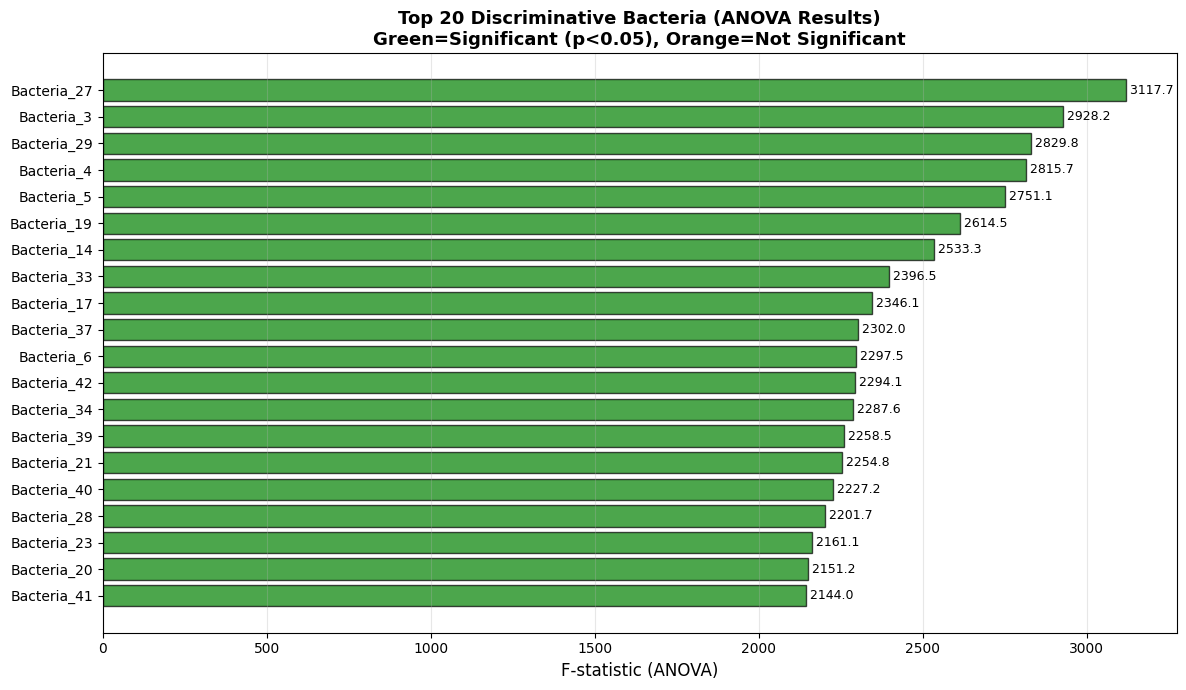

In [4]:
# ============================================
# TASK 3: VISUALIZATIONS
# ============================================

print("\n" + "="*60)
print("TASK 3: CREATING VISUALIZATIONS")
print("="*60)

# PLOT 1: ANOVA F-statistics (Top 20)
fig, ax = plt.subplots(figsize=(12, 7))

plot_data = anova_df.head(20).sort_values('f_statistic')

colors = ['green' if p < 0.05 else 'orange' for p in plot_data['p_value']]

bars = ax.barh(range(len(plot_data)), plot_data['f_statistic'], color=colors, alpha=0.7, edgecolor='black')

ax.set_yticks(range(len(plot_data)))
ax.set_yticklabels(plot_data['bacteria'], fontsize=10)
ax.set_xlabel('F-statistic (ANOVA)', fontsize=12)
ax.set_title('Top 20 Discriminative Bacteria (ANOVA Results)\nGreen=Significant (p<0.05), Orange=Not Significant', 
             fontsize=13, fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# Add value labels
for i, (idx, row) in enumerate(plot_data.iterrows()):
    ax.text(row['f_statistic'], i, f" {row['f_statistic']:.1f}", va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../results/06_anova_top20_bacteria.png', dpi=300, bbox_inches='tight')
print("✅ Plot 1 saved: 06_anova_top20_bacteria.png")
plt.show()

✅ Plot 2 saved: 07_correlation_heatmap.png


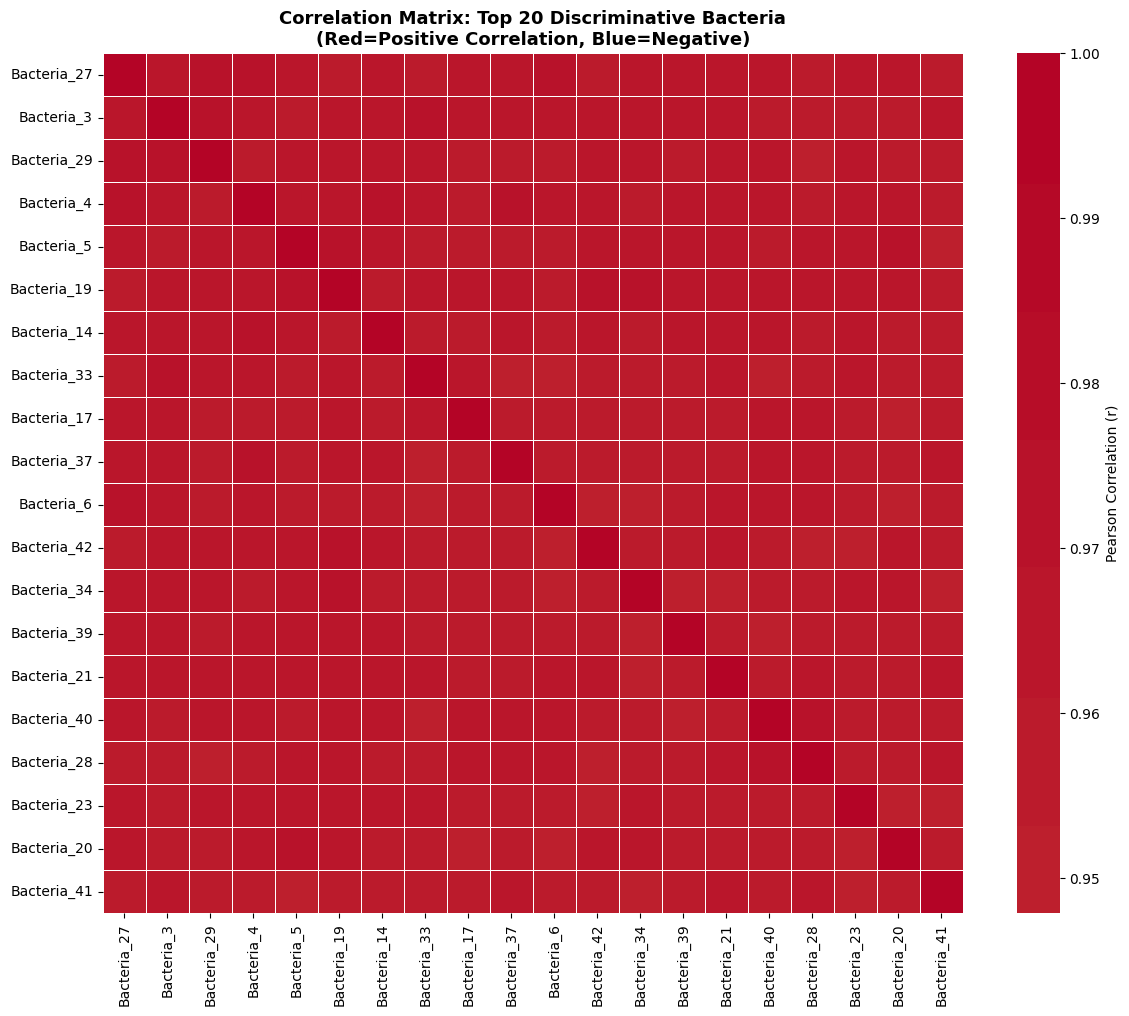

In [5]:
# PLOT 2: Correlation Heatmap (Top 20 bacteria)
fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, 
            cbar_kws={'label': 'Pearson Correlation (r)'}, 
            square=True, linewidths=0.5, ax=ax, annot=False)

ax.set_title('Correlation Matrix: Top 20 Discriminative Bacteria\n(Red=Positive Correlation, Blue=Negative)', 
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/07_correlation_heatmap.png', dpi=300, bbox_inches='tight')
print("✅ Plot 2 saved: 07_correlation_heatmap.png")
plt.show()

In [6]:
# ============================================
# TASK 5: DIMENSIONALITY REDUCTION WITH PCA
# ============================================

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("\n" + "="*60)
print("TASK 5: PCA DIMENSIONALITY REDUCTION")
print("="*60)

# Prepare data: Use top 20 bacteria only
X = feature_matrix[top_20_bacteria].values

# Standardize (PCA needs zero mean, unit variance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA: Reduce 20 dimensions → 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Calculate explained variance
explained_var = pca.explained_variance_ratio_
cumsum_var = np.cumsum(explained_var)

print("\n📊 PCA RESULTS")
print("-" * 60)
print(f"PC1 explains: {explained_var[0]*100:.2f}% of variance")
print(f"PC2 explains: {explained_var[1]*100:.2f}% of variance")
print(f"Together: {cumsum_var[1]*100:.2f}% of variance")

print("\nInterpretation:")
if cumsum_var[1] > 0.70:
    print(f"✅ EXCELLENT! 2D representation captures {cumsum_var[1]*100:.1f}% of information")
elif cumsum_var[1] > 0.50:
    print(f"✅ GOOD! 2D representation captures {cumsum_var[1]*100:.1f}% of information")
else:
    print(f"⚠️ Limited! 2D only captures {cumsum_var[1]*100:.1f}% - data is high-dimensional")

# Print which bacteria contribute most to PC1 and PC2
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

print("\n🎯 TOP BACTERIA CONTRIBUTING TO PC1 (Axis 1)")
print("-" * 60)
top_pc1 = np.argsort(np.abs(loadings[:, 0]))[-5:][::-1]
for rank, idx in enumerate(top_pc1, 1):
    bacteria_name = top_20_bacteria[idx]
    loading = loadings[idx, 0]
    print(f"{rank}. {bacteria_name:15} | Loading: {loading:7.3f}")

print("\n🎯 TOP BACTERIA CONTRIBUTING TO PC2 (Axis 2)")
print("-" * 60)
top_pc2 = np.argsort(np.abs(loadings[:, 1]))[-5:][::-1]
for rank, idx in enumerate(top_pc2, 1):
    bacteria_name = top_20_bacteria[idx]
    loading = loadings[idx, 1]
    print(f"{rank}. {bacteria_name:15} | Loading: {loading:7.3f}")

# Add PCA results to feature matrix
feature_matrix['PC1'] = X_pca[:, 0]
feature_matrix['PC2'] = X_pca[:, 1]

print("\n✅ PCA transformation complete!")


TASK 5: PCA DIMENSIONALITY REDUCTION

📊 PCA RESULTS
------------------------------------------------------------
PC1 explains: 96.27% of variance
PC2 explains: 0.42% of variance
Together: 96.68% of variance

Interpretation:
✅ EXCELLENT! 2D representation captures 96.7% of information

🎯 TOP BACTERIA CONTRIBUTING TO PC1 (Axis 1)
------------------------------------------------------------
1. Bacteria_27     | Loading:   0.990
2. Bacteria_19     | Loading:   0.990
3. Bacteria_4      | Loading:   0.989
4. Bacteria_3      | Loading:   0.989
5. Bacteria_5      | Loading:   0.988

🎯 TOP BACTERIA CONTRIBUTING TO PC2 (Axis 2)
------------------------------------------------------------
1. Bacteria_28     | Loading:   0.114
2. Bacteria_6      | Loading:   0.102
3. Bacteria_41     | Loading:   0.092
4. Bacteria_34     | Loading:  -0.091
5. Bacteria_20     | Loading:  -0.087

✅ PCA transformation complete!


✅ Plot 3 saved: 08_pca_healthy_vs_ibd.png


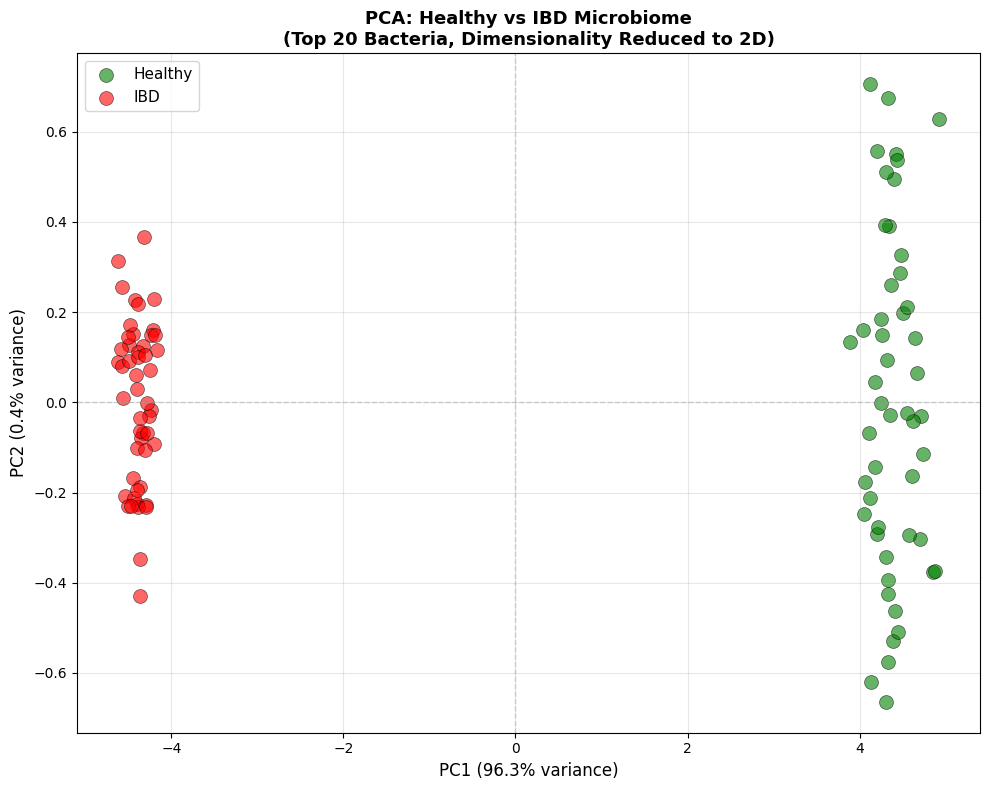

In [7]:
# PLOT 3: PCA Scatter Plot (Healthy vs IBD in 2D space)
fig, ax = plt.subplots(figsize=(10, 8))

# Plot by disease status
healthy_mask = feature_matrix['disease_status'] == 'healthy'
ibd_mask = feature_matrix['disease_status'] == 'IBD'

ax.scatter(feature_matrix.loc[healthy_mask, 'PC1'], 
          feature_matrix.loc[healthy_mask, 'PC2'],
          c='green', s=100, alpha=0.6, label='Healthy', edgecolor='black', linewidth=0.5)

ax.scatter(feature_matrix.loc[ibd_mask, 'PC1'], 
          feature_matrix.loc[ibd_mask, 'PC2'],
          c='red', s=100, alpha=0.6, label='IBD', edgecolor='black', linewidth=0.5)

ax.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('PCA: Healthy vs IBD Microbiome\n(Top 20 Bacteria, Dimensionality Reduced to 2D)', 
             fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend(fontsize=11, loc='best')
ax.axhline(0, color='gray', linestyle='--', alpha=0.3, linewidth=1)
ax.axvline(0, color='gray', linestyle='--', alpha=0.3, linewidth=1)

plt.tight_layout()
plt.savefig('../results/08_pca_healthy_vs_ibd.png', dpi=300, bbox_inches='tight')
print("✅ Plot 3 saved: 08_pca_healthy_vs_ibd.png")
plt.show()

In [8]:
# ============================================
# TASK 7: PREPARE DATASET FOR ML MODEL
# ============================================

print("\n" + "="*60)
print("TASK 7: PREPARE ML-READY DATASET")
print("="*60)

# Create clean dataset: Top 20 bacteria + disease status
ml_dataset = feature_matrix[top_20_bacteria + ['disease_status']].copy()

# Standardize features (ML models like normalized data)
ml_dataset_scaled = ml_dataset.copy()
ml_dataset_scaled[top_20_bacteria] = scaler.fit_transform(ml_dataset[top_20_bacteria])

# Save both versions
ml_dataset.to_csv('../results/phase3_ml_dataset_raw.csv', index=False)
ml_dataset_scaled.to_csv('../results/phase3_ml_dataset_scaled.csv', index=False)

print(f"\n✅ ML DATASET CREATED")
print("-" * 60)
print(f"Samples: {ml_dataset.shape[0]}")
print(f"Features: {ml_dataset.shape[1] - 1} bacteria")
print(f"Target: disease_status (healthy, IBD)")
print(f"\nDisease distribution:")
print(ml_dataset['disease_status'].value_counts().to_string())

print(f"\n✅ Saved: phase3_ml_dataset_raw.csv")
print(f"✅ Saved: phase3_ml_dataset_scaled.csv")

# Summary statistics
print(f"\n📊 FEATURE STATISTICS (Top 20 bacteria)")
print("-" * 60)
stats_summary = ml_dataset[top_20_bacteria].describe().loc[['mean', 'std', 'min', 'max']]
print(stats_summary)


TASK 7: PREPARE ML-READY DATASET

✅ ML DATASET CREATED
------------------------------------------------------------
Samples: 100
Features: 20 bacteria
Target: disease_status (healthy, IBD)

Disease distribution:
disease_status
healthy    50
IBD        50

✅ Saved: phase3_ml_dataset_raw.csv
✅ Saved: phase3_ml_dataset_scaled.csv

📊 FEATURE STATISTICS (Top 20 bacteria)
------------------------------------------------------------
      Bacteria_27  Bacteria_3  Bacteria_29  Bacteria_4  Bacteria_5  \
mean    150.26500   148.36500    149.98000  149.635000  150.040000   
std      50.86715    51.59163     52.17782   50.939995   50.934533   
min      87.50000    86.00000     88.00000   87.000000   84.500000   
max     220.00000   233.00000    227.00000  233.000000  229.000000   

      Bacteria_19  Bacteria_14  Bacteria_33  Bacteria_17  Bacteria_37  \
mean   150.645000   149.560000   148.335000   151.200000   148.145000   
std     50.340472    50.784466    49.920697    52.234466    47.754597   

In [9]:
# ============================================
# TASK 8: PHASE 3 SUMMARY
# ============================================

phase3_summary = f"""
# PHASE 3: FEATURE SELECTION & DIMENSIONALITY REDUCTION
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

## STATISTICAL TESTING

### ANOVA Results
- Total bacteria tested: 50
- Significant bacteria (p < 0.05): {anova_df['significant'].sum()}
- Selected for ML: Top 20

### Top 3 Most Discriminative Bacteria
{anova_df.head(3)[['bacteria', 'f_statistic', 'p_value', 'eta_squared']].to_string(index=False)}

## CORRELATION ANALYSIS

### Strong Correlations Found
- Positive (co-abundant): {len(strong_corr_df[strong_corr_df['correlation'] > 0])} pairs
- Negative (inverse): {len(strong_corr_df[strong_corr_df['correlation'] < 0])} pairs

## DIMENSIONALITY REDUCTION (PCA)

### Variance Explained
- PC1: {explained_var[0]*100:.2f}%
- PC2: {explained_var[1]*100:.2f}%
- **Total (2D): {cumsum_var[1]*100:.2f}%**

Interpretation: {cumsum_var[1]*100:.1f}% of bacterial variance captured in 2D visualization.

### Key Bacteria (PC1 - Main Axis)
{pd.DataFrame({
    'Bacteria': [top_20_bacteria[i] for i in np.argsort(np.abs(loadings[:, 0]))[-5:][::-1]],
    'Loading': loadings[np.argsort(np.abs(loadings[:, 0]))[-5:][::-1], 0]
}).to_string(index=False)}

## ML DATASET PREPARED

- Samples: 100 (50 healthy, 50 IBD)
- Features: 20 bacteria
- Ready for Phase 4 modeling

## FILES GENERATED

1. phase3_anova_results.csv - ANOVA statistics for all bacteria
2. phase3_correlation_matrix.csv - Pearson correlation matrix
3. phase3_ml_dataset_raw.csv - 20 bacteria + labels (original scale)
4. phase3_ml_dataset_scaled.csv - 20 bacteria + labels (standardized)
5. 06_anova_top20_bacteria.png - ANOVA bar chart
6. 07_correlation_heatmap.png - Correlation visualization
7. 08_pca_healthy_vs_ibd.png - 2D PCA scatter plot

## NEXT PHASE

Phase 4: Machine Learning Model
- Train Random Forest on top 20 bacteria
- Cross-validation & hyperparameter tuning
- Evaluate accuracy, AUC-ROC, confusion matrix
- Feature importance ranking
"""

with open('../results/PHASE3_SUMMARY.txt', 'w') as f:
    f.write(phase3_summary)

print(phase3_summary)
print("\n✅ Saved: PHASE3_SUMMARY.txt")


# PHASE 3: FEATURE SELECTION & DIMENSIONALITY REDUCTION
Generated: 2026-06-08 13:56:13

## STATISTICAL TESTING

### ANOVA Results
- Total bacteria tested: 50
- Significant bacteria (p < 0.05): 50
- Selected for ML: Top 20

### Top 3 Most Discriminative Bacteria
   bacteria  f_statistic      p_value  eta_squared
Bacteria_27  3117.728972 4.218796e-76     0.969525
 Bacteria_3  2928.191347 8.286616e-75     0.967616
Bacteria_29  2829.790029 4.188736e-74     0.966528

## CORRELATION ANALYSIS

### Strong Correlations Found
- Positive (co-abundant): 190 pairs
- Negative (inverse): 0 pairs

## DIMENSIONALITY REDUCTION (PCA)

### Variance Explained
- PC1: 96.27%
- PC2: 0.42%
- **Total (2D): 96.68%**

Interpretation: 96.7% of bacterial variance captured in 2D visualization.

### Key Bacteria (PC1 - Main Axis)
   Bacteria  Loading
Bacteria_27 0.989581
Bacteria_19 0.989528
 Bacteria_4 0.989400
 Bacteria_3 0.988640
 Bacteria_5 0.987987

## ML DATASET PREPARED

- Samples: 100 (50 healthy, 50 IBD)
- 